# Initial setup

In [ ]:
%pip install -q langchain[community] langchain-openai langchain-google-genai langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.3/713.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 490.2/490.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.9/234.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-au

In [ ]:
AVAILABLE_MODELS = {
    # "small": {
    #     "name": "google_genai:gemini-2.5-flash",
    #     "backend": "langchain",
    # },
    # "small": {
    #     "name": "Qwen/Qwen3-1.7B",
    #     "backend": "huggingface",
    # },
    # "small": {
    #     "name": "google/gemma-2-2b-it",
    #     "backend": "huggingface",
    # },
    # "medium": {
    #     "name": "google_genai:gemini-2.0-flash",
    #     "backend": "langchain",
    # },
    # "medium": {
    #     "name": "google_genai:gemini-2.5-flash",
    #     "backend": "langchain",
    # },
    # "medium": {
    #     "name": "google_genai:gemini-1.5-flash",
    #     "backend": "langchain",
    # },
    # "medium": {
    #     "name": "openai/gpt-oss-20b",
    #     "backend": "huggingface",
    # },
    "small": {
        "name": "Qwen/Qwen3-4B-Instruct-2507",
        "backend": "huggingface",
        "specs": {
            "n_params_b": 4,
        }
    },
    "medium": {
        "name": "nvidia/NVIDIA-Nemotron-Nano-12B-v2",
        "backend": "huggingface",
        "specs": {
            "n_params_b": 12,
        }
    },
    "large": {
        "name": "gpt-4.1",
        "backend": "langchain",
        "specs": {
            "n_params_b": 1760,
        }
    },
}

In [ ]:
import os

Google Colab Setup

In [ ]:
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get('google_api_key')
os.environ["OPENAI_API_KEY"] = userdata.get('openai_api_key')
os.environ["HF_TOKEN"] = userdata.get('hf_token')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import userdata
root_folder = userdata.get('llm_router_folder')

Local Setup

- Create a file named `.env` and add a line for each variable associated to its value like this : `VARIABLE=VALUE`
- Uncomment the following code.
- Update `root_folder` value to the path where the generated files will be stored.

The required variables are \:
- `GOOGLE_API_KEY`
- `OPENAI_API_KEY`
- `HF_TOKEN`

In [ ]:
# from dotenv import load_dotenv
# load_dotenv(".env")

# root_folder = "..."

In [ ]:
data_path = os.path.join(root_folder, 'data/features.csv')

# Data Loading

In [ ]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_json("hf://datasets/hkust-nlp/deita-complexity-scorer-data/complexity_llama_reward_trn.json", lines=True)

print("Shape:", df.shape)

print("\nFirst 5 rows:")
df.head()

Shape: (9481, 2)

First 5 rows:


,input,target
0,You are a helpful assistant. Please identify t...,6
1,You are a helpful assistant. Please identify t...,5
2,You are a helpful assistant. Please identify t...,3
3,You are a helpful assistant. Please identify t...,5
4,You are a helpful assistant. Please identify t...,2


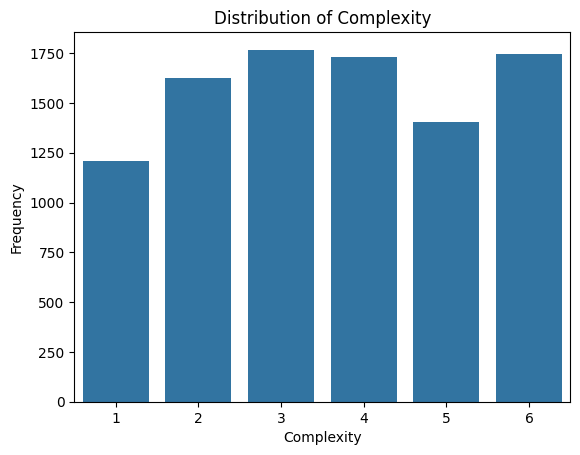

In [ ]:
sns.barplot(x=df["target"].value_counts().index, y=df["target"].value_counts())
plt.xlabel("Complexity")
plt.ylabel("Frequency")
plt.title("Distribution of Complexity")
plt.show()

In [ ]:
df["query"] = df["input"].str.extract(r"Query: (?P<query>.*)\s{2,}##Complexity:", flags=re.DOTALL)

df["query"].head()

,query
0,Add a requirement that the twist ending must i...
1,Given the concerning problem of hypoxia in Lak...
2,Add a constraint that the customer service age...
3,What's a five letter verb that denotes the act...
4,Open up a discussion about a given topic.


In [ ]:
df.isna().sum()

,0
input,0
target,0
query,0


# Data preprocessing

In [ ]:
import spacy
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
import torch

In [ ]:
nlp = spacy.load("en_core_web_sm")  # or "fr_core_news_sm"
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
perplexity_model = AutoModelForCausalLM.from_pretrained("distilgpt2")
embedder = SentenceTransformer("paraphrase-MiniLM-L6-v2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def calc_perplexity(text):
    enc = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        logits = perplexity_model(**enc).logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = enc["input_ids"][..., 1:].contiguous()
    loss_fct = torch.nn.CrossEntropyLoss(reduction='mean')
    loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)),
                    shift_labels.view(-1))
    return np.exp(loss.item())

In [ ]:
def extract_features(text):
    doc = nlp(text)

    words = [t.text for t in doc]

    features = {}

    # A — lexicales
    features["num_chars"] = len(text)
    features["num_words"] = len(words)
    features["num_tokens"] = len([t for t in doc])
    features["avg_word_length"] = np.mean([len(w) for w in words])
    features["unique_word_ratio"] = len(set(words)) / max(1, len(words))

    # B — syntaxiques
    sentences = list(doc.sents)
    features["num_sentences"] = len(sentences)
    features["avg_sentence_length"] = features["num_words"] / max(1, len(sentences))
    features["question_count"] = text.count("?")
    features["comma_count"] = text.count(",")
    features["semicolon_count"] = text.count(";")
    features["stopword_ratio"] = sum(1 for w in doc if w.is_stop) / max(1, len(doc))

    # C — mots-clés (simplifié)
    reasoning_keywords = ["expliquer", "analyse", "raisonner", "justifie"]
    features["requires_reasoning"] = int(any(k in text.lower() for k in reasoning_keywords))

    translate_keywords = ["traduis", "translate", "en anglais", "en français"]
    features["is_translation"] = int(any(k in text.lower() for k in translate_keywords))

    code_keywords = ["code", "python", "fonction", "class", "script"]
    features["is_code"] = int(any(k in text.lower() for k in code_keywords))

    # D — perplexité
    features["perplexity"] = calc_perplexity(text)

    # D2 — embeddings
    # features["embedding"] = embedder.encode(text)

    return features

In [ ]:
result = extract_features(df["query"][0])

result.update({
    "query": df["query"][0],
    "target": df["target"][0],
})

pd.Series(result)

,0
num_chars,440
num_words,75
num_tokens,75
avg_word_length,4.96
unique_word_ratio,0.746667
num_sentences,3
avg_sentence_length,25.0
question_count,0
comma_count,1
semicolon_count,0


In [ ]:
features_df = df["query"].apply(extract_features).apply(pd.Series)

In [ ]:
prompts_df = pd.concat([df, features_df], axis=1)

In [ ]:
prompts_df.to_csv(data_path, index=False)

# LLM Calling

In [ ]:
import time
import json
from langchain.chat_models import init_chat_model
from huggingface_hub import InferenceClient

In [ ]:
def call_model_langchain(model: str, prompt: str, **model_kwargs):
    chat = init_chat_model(model=model, **model_kwargs)

    # 1. Start of timing
    t_start = time.perf_counter()
    completion_stream = chat.stream(prompt)
    t_end = time.perf_counter()

    response = None
    first_token_received = False
    t_first_token = 0

    for chunk in completion_stream:
        if not first_token_received:
            t_first_token = time.perf_counter()
            first_token_received = True
        response = chunk if response is None else response + chunk

    # 2. End of timing
    t_end = time.perf_counter()

    # Get usage data (temporal metrics)
    usage = response.usage_metadata
    prompt_tokens = usage.get("input_tokens", 0)
    completion_tokens = usage.get("output_tokens", 0)

    total_time = t_end - t_start
    ttft = t_first_token - t_start if first_token_received else total_time

    metrics = {
        "total_time": total_time,
        "time_to_first_token": ttft,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": prompt_tokens + completion_tokens,
        "throughput": completion_tokens / total_time if total_time > 0 else 0
    }

    # Return the response and metrics for checking
    return response.content, metrics

In [ ]:
from transformers import AutoTokenizer

# Cache to store tokenizers that have already been loaded and avoid reloading them with each call
tokenizer_cache = {}

def get_token_count(model_name: str, text: str) -> int:
    """
    Charge le tokenizer approprié et compte le nombre de tokens pour le texte donné.
    """
    try:
        # 1. Get tokenizer or load it from the cache
        if model_name not in tokenizer_cache:
            tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
            tokenizer_cache[model_name] = tokenizer
        else:
            tokenizer = tokenizer_cache[model_name]

        # 2. Text tokenization as Numpy array
        tokens = tokenizer(text, return_tensors="np")

        # 3. Count tokens
        token_count = tokens['input_ids'].shape[1]

        return token_count

    except Exception as e:
        print(f"An error occured during tokenization for the model {model_name}: {e}")
        return 0

In [ ]:
def call_model_huggingface(model: str, prompt: str, **model_kwargs):
    client = InferenceClient(api_key=os.environ["HF_TOKEN"])
    messages = [{"role": "user", "content": prompt}]

    # 1. Start of timing
    t_start = time.perf_counter()

    # Using streaming functionality for TtFT (Time-to-First-Token)
    completion_stream = client.chat.completions.create(
        model=model,
        messages=messages,
        stream=True,
        **model_kwargs
    )

    response_content = ""
    first_token_received = False
    t_first_token = 0

    for chunk in completion_stream:
        if not first_token_received and chunk.choices and chunk.choices[0].delta.content:
            t_first_token = time.perf_counter()
            first_token_received = True

        if chunk.choices and chunk.choices[0].delta.content:
            response_content += chunk.choices[0].delta.content

    # 2. End of timing
    t_end = time.perf_counter()

    # Compute temporal metrics
    total_time = t_end - t_start
    ttft = t_first_token - t_start if first_token_received else total_time

    # Count tokens
    prompt_tokens = get_token_count(model, prompt)
    completion_tokens = get_token_count(model, response_content)

    # 3. Troughput: Number of tokens per unit of time
    throughput = completion_tokens / total_time if total_time > 0 else 0

    # Simplified metrics based on time
    metrics = {
        "total_time": total_time,
        "time_to_first_token": ttft,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": prompt_tokens + completion_tokens,
        "throughput": throughput,
    }

    return response_content, metrics


In [ ]:
def call_model(model_conf: dict, prompt: str):
    backend = model_conf["backend"]

    if backend == "langchain":
        return call_model_langchain(model_conf["name"], prompt, **model_conf.get("kwargs", {}))

    if backend == "huggingface":
        return call_model_huggingface(model_conf["name"], prompt, **model_conf.get("kwargs", {}))

    raise ValueError(f"Backend '{backend}' inconnu.")

# Experiment

In [ ]:
response, metrics = call_model(AVAILABLE_MODELS["small"], "hello")

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]


Metrics:
{
  "total_time": 1.1754474760000448,
  "time_to_first_token": 1.0605394840001736,
  "prompt_tokens": 1,
  "completion_tokens": 11,
  "total_tokens": 12,
  "throughput": 9.35813826189166
}

Answer:
Hello! 😊 How can I assist you today?


In [ ]:
response, metrics = call_model(AVAILABLE_MODELS["medium"], "hello")

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/422 [00:00<?, ?B/s]


Metrics:
{
  "total_time": 1.2708973789999618,
  "time_to_first_token": 0.7186559080000734,
  "prompt_tokens": 2,
  "completion_tokens": 79,
  "total_tokens": 81,
  "throughput": 62.16080173378214
}

Answer:
Okay, the user just said "hello". That's a greeting. I should respond appropriately. Let me make sure to acknowledge their greeting and offer help. Maybe say something like "Hello! How can I assist you today?" That's friendly and opens the door for them to ask questions. I should keep it simple and welcoming.
</think>

Hello! How can I assist you today?



In [ ]:
response, metrics = call_model(AVAILABLE_MODELS["large"], "hello")

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)


Metrics:
{
  "total_time": 2.166763207000031,
  "time_to_first_token": 1.8057423420000305,
  "prompt_tokens": 8,
  "completion_tokens": 9,
  "total_tokens": 17,
  "throughput": 4.1536610788498916
}

Answer:
Hello! How can I help you today?


# Benchmark

In [ ]:
import random
from typing import List, Dict, Any, Callable

In [ ]:
def run_single_experiment(
    model_key: str,
    model_config: Dict[str, str],
    prompt: str,
    call_func: Callable[[str, str], tuple]
) -> Dict[str, Any]:
    """
    Executes a single model call and collects all metrics.

    Args:
        model_key: Descriptive key for the model ('small', 'medium', 'large').
        model_config: Model configuration dictionary (name, backend).
        prompt: The prompt to execute.
        call_func: The appropriate API call function (LangChain or Hugging Face).

    Returns:
        Dictionary containing all metrics and metadata.
    """

    try:
        # Return a dictionnary containing response and metrics
        response, metrics = call_func(model_config['name'], prompt)

        # Add essential metadata
        metrics['model_key'] = model_key
        metrics['model_name'] = model_config['name']
        metrics['backend'] = model_config['backend']
        metrics['prompt'] = prompt
        metrics['response'] = response

        return metrics
    except Exception as e:
        print(f"Erreur d'exécution pour {model_key} avec prompt '{prompt[:30]}...': {e}")
        # Prevent process interuption in the event of an error
        return {
            'model_key': model_key,
            'model_name': model_config['name'],
            'backend': model_config['backend'],
            'prompt': prompt,
            'total_time': None,
            'error': str(e)
        }

In [ ]:
def run_data_collection_phase(
    models: Dict[str, Dict[str, str]],
    prompts: List[str],
    repetitions: int,
    phase_name: str,
    call_langchain: Callable,
    call_huggingface: Callable,
    log_interval: int = 50,
) -> pd.DataFrame:
    """
    Executes a collection phase (calibration or production) with repetitions.

    Args:
        models: Dictionary of models (your list of small, medium, large).
        prompts: List of prompts to test.
        repetitions: Number of times each prompt will be executed per model.
        phase_name: Name of the phase ('calibration' or 'production').
        call_langchain: Function to call LangChain models.
        call_huggingface: Function to call Hugging Face models.

    Returns:
        pd.DataFrame: A DataFrame containing all the results of the experiments.
    """
    all_results = []

    print(f"\n🚀 Phase starting : {phase_name.upper()} ({len(prompts)} prompts x {repetitions} repetitions)")

    for model_key, config in models.items():
        backend = config['backend']
        print(f"  -> Testing model {model_key} ({config['name']}) [{backend}]...")

        if backend == 'langchain':
            call_func = call_langchain
        elif backend == 'huggingface':
            call_func = call_huggingface
        else:
            print(f"    Unsupported backend {backend}. Ignored.")
            continue

        for i, prompt in enumerate(prompts):
            for rep in range(1, repetitions+1):
                # Small pause to avoid API overload
                time.sleep(random.uniform(0.1, 0.5))

                result = run_single_experiment(model_key, config, prompt, call_func)
                result['repetition'] = rep
                result['phase'] = phase_name
                all_results.append(result)

                # Progression display
                if (i * repetitions + rep) % log_interval == 0 and (i * repetitions + rep) > 0:
                    print(f"    ... {i * repetitions + rep} completed calls.")

    return pd.DataFrame(all_results)

In [ ]:
def execute_full_benchmarking(
    models: Dict[str, Dict[str, str]],
    calibration_prompts: List[str],
    production_prompts: List[str],
    calib_repetitions: int = 20,
    prod_repetitions: int = 5,
    output_filename: str = 'llm_metrics_data.csv',
    save_mode: str = 'w',
    call_langchain: Callable = None,
    call_huggingface: Callable = None,
    log_interval: int = 50,
):
    """
    Orchestrates the calibration and production phases and saves the result.
    """

    # 1. Call function validation (Must be defined by the user)
    if call_langchain is None or call_huggingface is None:
        raise ValueError("API call functions (LangChain and HuggingFace) must be provided.")

    print("--- Starting Benchmark ---")

    # --- PHASE 1 : CALIBRATION ---
    calib_df = run_data_collection_phase(
        models=models,
        prompts=calibration_prompts,
        repetitions=calib_repetitions,
        phase_name='calibration',
        call_langchain=call_langchain,
        call_huggingface=call_huggingface,
        log_interval=log_interval,
    )

    # --- PHASE 2 : PRODUCTION ---
    prod_df = run_data_collection_phase(
        models=models,
        prompts=production_prompts,
        repetitions=prod_repetitions,
        phase_name='production',
        call_langchain=call_langchain,
        call_huggingface=call_huggingface,
        log_interval=log_interval,
    )

    # --- 3. CONCATENATION AND CLEANING ---
    final_df = pd.concat([calib_df, prod_df], ignore_index=True)

    # Time values conversion for analysis
    final_df['total_time'] = pd.to_numeric(final_df['total_time'], errors='coerce')
    final_df['throughput'] = pd.to_numeric(final_df['throughput'], errors='coerce')

    print(f"\n✅ Ending Benchmark. {len(final_df)} records collected.")

    # --- 4. CSV STORING (on Colab) ---
    final_df.to_csv(output_filename, index=False, mode=save_mode)
    print(f"💾 Data saved in '{output_filename}'.")

    # Download the resulting file from Colab
    # from google.colab import files
    # files.download(output_filename)

    return final_df

In [ ]:
prompts_df = pd.read_csv(data_path)
prompts_df.head()

,input,target,query,num_chars,num_words,num_tokens,avg_word_length,unique_word_ratio,num_sentences,avg_sentence_length,question_count,comma_count,semicolon_count,stopword_ratio,requires_reasoning,is_translation,is_code,perplexity
0,You are a helpful assistant. Please identify t...,6,Add a requirement that the twist ending must i...,440.0,75.0,75.0,4.960000,0.746667,3.0,25.0,0.0,1.0,0.0,0.480000,0.0,0.0,0.0,49.539368
1,You are a helpful assistant. Please identify t...,5,Given the concerning problem of hypoxia in Lak...,352.0,56.0,56.0,5.375000,0.857143,1.0,56.0,0.0,1.0,0.0,0.410714,0.0,0.0,0.0,43.078626
2,You are a helpful assistant. Please identify t...,3,Add a constraint that the customer service age...,414.0,72.0,72.0,4.847222,0.638889,3.0,24.0,0.0,3.0,0.0,0.486111,0.0,0.0,0.0,28.423706
3,You are a helpful assistant. Please identify t...,5,What's a five letter verb that denotes the act...,335.0,66.0,66.0,4.242424,0.772727,2.0,33.0,1.0,3.0,0.0,0.500000,0.0,0.0,0.0,43.378688
4,You are a helpful assistant. Please identify t...,2,Open up a discussion about a given topic.,41.0,9.0,9.0,3.777778,0.888889,1.0,9.0,0.0,0.0,0.0,0.444444,0.0,0.0,0.0,113.025769


In [ ]:
CALIBRATION_PROMPTS_PER_COMPLEXITY_SIZE = 1

CALIBRATION_PROMPTS = prompts_df.groupby("target").agg({
    "query": lambda s: pd.Series.head(s, CALIBRATION_PROMPTS_PER_COMPLEXITY_SIZE)
}).explode("query")

print(f"Calibration dataset size: {len(CALIBRATION_PROMPTS)}")
CALIBRATION_PROMPTS.head()

Calibration dataset size: 6


,query
target,
1,Compose a signup form for a newsletter.
2,Open up a discussion about a given topic.
3,Add a constraint that the customer service age...
4,Revise the prompt to mandate a multi-step reas...
5,Given the concerning problem of hypoxia in Lak...


In [ ]:
PRODUCTION_PROMPTS_PER_COMPLEXITY_SIZE = 2

PRODUCTION_PROMPTS = prompts_df.groupby("target").agg({
    "query": lambda s: (
        s.iloc[CALIBRATION_PROMPTS_PER_COMPLEXITY_SIZE:]
        .head(PRODUCTION_PROMPTS_PER_COMPLEXITY_SIZE)
    )
}).explode("query")

print(f"Production dataset size: {len(PRODUCTION_PROMPTS)}")
PRODUCTION_PROMPTS.sample(frac=1).head()

Production dataset size: 12


,query
target,
5,Can you provide a comprehensive analysis of th...
4,"In the given prompt, expand on the intricate d..."
5,What's a five letter verb that denotes the act...
6,Can you expand on the given prompt by providin...
4,In the context of a modern open-plan office wi...


In [ ]:
benchmark_data_path = os.path.join(root_folder, "benchmark_result.csv") # Output file for the benchmark

In [ ]:
bench_df = execute_full_benchmarking(
    models=AVAILABLE_MODELS,
    calibration_prompts=CALIBRATION_PROMPTS["query"],
    production_prompts=PRODUCTION_PROMPTS["query"],
    calib_repetitions=2,
    prod_repetitions=1,
    output_filename=benchmark_data_path,
    call_langchain=call_model_langchain,
    call_huggingface=call_model_huggingface,
    log_interval=1,
)

--- Début du Benchmarking ---

🚀 Démarrage de la phase : CALIBRATION (6 prompts x 2 répétitions)
  -> Test du modèle small (Qwen/Qwen3-4B-Instruct-2507) [huggingface]...
    ... 1 appels complétés.
    ... 2 appels complétés.
    ... 3 appels complétés.
    ... 4 appels complétés.
    ... 5 appels complétés.
    ... 6 appels complétés.
    ... 7 appels complétés.
    ... 8 appels complétés.
    ... 9 appels complétés.
    ... 10 appels complétés.
    ... 11 appels complétés.
    ... 12 appels complétés.
  -> Test du modèle medium (nvidia/NVIDIA-Nemotron-Nano-12B-v2) [huggingface]...
    ... 1 appels complétés.
    ... 2 appels complétés.
    ... 3 appels complétés.
    ... 4 appels complétés.
    ... 5 appels complétés.
    ... 6 appels complétés.
    ... 7 appels complétés.
    ... 8 appels complétés.
    ... 9 appels complétés.
    ... 10 appels complétés.
    ... 11 appels complétés.
    ... 12 appels complétés.
  -> Test du modèle large (gpt-4.1) [langchain]...
    ... 1 appels com

# Benchmark analysis

In [ ]:
bench_df = pd.read_csv(benchmark_data_path)
print(bench_df.shape)
bench_df.head()

(72, 13)


,total_time,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,throughput,model_key,model_name,backend,prompt,response,repetition,phase
0,7.718686,1.103422,8,681,689,88.227450,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Compose a signup form for a newsletter.,### Newsletter Signup Form \n\n**Subject:** S...,1,calibration
1,5.463643,0.978237,8,465,473,85.108056,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Compose a signup form for a newsletter.,### Newsletter Signup Form \n\n**Subject:** J...,2,calibration
2,3.035984,0.982658,9,211,220,69.499698,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Open up a discussion about a given topic.,Sure! Let's open up a discussion about **the f...,1,calibration
3,5.412214,0.693831,9,489,498,90.351198,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Open up a discussion about a given topic.,Absolutely! Let's dive into a thought-provokin...,2,calibration
4,4.348920,0.757653,72,372,444,85.538476,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Add a constraint that the customer service age...,Certainly. Here's a clear and professional add...,1,calibration


In [ ]:
def estimate_joules(n_tokens, n_params, hardware_efficiency=10**13):
    total_flops = 2 * n_tokens * n_params * 10**9
    joules_per_second = total_flops / hardware_efficiency
    return joules_per_second

In [ ]:
def enrich_benchmark(row):
    row = row.to_dict()
    model_conf = AVAILABLE_MODELS[row["model_key"]]
    model_specs = model_conf["specs"]
    row["estimated_joules"] = estimate_joules(row["total_tokens"], model_specs["n_params_b"])
    return row

In [ ]:
bench_df = bench_df.apply(enrich_benchmark, axis=1).apply(pd.Series)
bench_df.head()

,total_time,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,throughput,model_key,model_name,backend,prompt,response,repetition,phase,estimated_joules
0,7.718686,1.103422,8,681,689,88.227450,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Compose a signup form for a newsletter.,### Newsletter Signup Form \n\n**Subject:** S...,1,calibration,0.5512
1,5.463643,0.978237,8,465,473,85.108056,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Compose a signup form for a newsletter.,### Newsletter Signup Form \n\n**Subject:** J...,2,calibration,0.3784
2,3.035984,0.982658,9,211,220,69.499698,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Open up a discussion about a given topic.,Sure! Let's open up a discussion about **the f...,1,calibration,0.1760
3,5.412214,0.693831,9,489,498,90.351198,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Open up a discussion about a given topic.,Absolutely! Let's dive into a thought-provokin...,2,calibration,0.3984
4,4.348920,0.757653,72,372,444,85.538476,small,Qwen/Qwen3-4B-Instruct-2507,huggingface,Add a constraint that the customer service age...,Certainly. Here's a clear and professional add...,1,calibration,0.3552


In [ ]:
bench_summary_df = bench_df.groupby(['model_key']).agg({
    "model_name": "first",
    "throughput": "mean",
    "estimated_joules": "mean",
})

bench_summary_df = bench_summary_df.reset_index()
bench_summary_df

,model_key,model_name,throughput,estimated_joules
0,large,gpt-4.1,35.547893,177.730667
1,medium,nvidia/NVIDIA-Nemotron-Nano-12B-v2,131.120909,5.361000
2,small,Qwen/Qwen3-4B-Instruct-2507,80.060330,1.034633


# Modelization

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

import joblib

In [ ]:
# Load data
df = pd.read_csv(data_path)

In [ ]:
df.shape

(9481, 18)

In [ ]:
# df = df.drop(columns=["embedding"])

In [ ]:
X = df.drop(["input", "target", "query"], axis=1)
y = df["target"]

In [ ]:
X.dtypes

,0
num_chars,float64
num_words,float64
num_tokens,float64
avg_word_length,float64
unique_word_ratio,float64
num_sentences,float64
avg_sentence_length,float64
question_count,float64
comma_count,float64
semicolon_count,float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Create a pipeline with scaling and a random forest regressor

In [ ]:
scaler = StandardScaler()
rf_reg = RandomForestRegressor(n_estimators=250, max_depth=10, random_state=42)

In [ ]:
model_ppln = Pipeline([
    ('scaler', scaler),
    ('rf', rf_reg)
])

model_ppln.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=10, n_estimators=250,
                                       random_state=42))])

In [ ]:
y_pred = model_ppln.predict(X_test)

print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 score: {r2_score(y_test, y_pred)}")

RMSE: 1.0740386167103426
R2 score: 0.5795818005023973


Save model

In [ ]:
model_path = os.path.join(root_folder, "model.joblib")

In [ ]:
joblib.dump(model_ppln, model_path)

['/content/drive/MyDrive/Home/School/ESILV/A4-DIA/Green AI/llm_router/model.joblib']

# Pipeline

In [ ]:
def random_selector(prompt: str, model_list=AVAILABLE_MODELS):
    """
    Randomly return a model from the available ones.
    """
    chosen_key = random.choice(list(model_list.keys()))
    return model_list[chosen_key]

In [ ]:
def orchestrate(prompt, selector=random_selector, model_list=AVAILABLE_MODELS):
    model_conf = selector(prompt, model_list)
    print(f"[Router] Chosen model : {model_conf['name']}")

    response, metrics = call_model(model_conf, prompt)

    model_specs = model_conf["specs"]
    metrics["estimated_joules"] = estimate_joules(metrics["total_tokens"], model_specs["n_params_b"])
    return response, metrics

# Random Forest Regressor-based Selector

In [ ]:
complexity_reg = joblib.load(model_path)

In [ ]:
def rf_reg_llm_selector(prompt: str, model_list=AVAILABLE_MODELS):
    """
    From the complexity regressor, this selector choose the best llm based on the score attributed to the prompt.
    """
    # Extract features
    features = extract_features(prompt)
    # features.pop("embedding")
    x = pd.DataFrame([features])

    # Predict complexity
    complexity = complexity_reg.predict(x)
    print(f"\n[Selector] Complexity: {complexity}\n")

    # Return selected model config
    if complexity <= 2:
        chosen_key = "small"
    elif complexity <= 4:
        chosen_key = "medium"
    else:
        chosen_key = "large"
    return model_list[chosen_key]

# Inference

Simple prompt (Small)

In [ ]:
response, metrics = orchestrate(
    "Hello, how could I cook a burger for my aunt ?",
    selector=rf_reg_llm_selector,
    model_list=AVAILABLE_MODELS,
)

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)


[Selector] Complexity: [1.33723439]

[Router] Chosen model : Qwen/Qwen3-4B-Instruct-2507

Metrics:
{
  "total_time": 7.657271396000169,
  "time_to_first_token": 1.306206720000091,
  "prompt_tokens": 12,
  "completion_tokens": 664,
  "total_tokens": 676,
  "throughput": 86.71496224449419,
  "estimated_joules": 0.5408
}

Answer:
Hello! That’s a great question — cooking a burger for your aunt is a thoughtful and delicious gesture! Here’s a simple, delicious, and safe way to make a perfect burger for her:

### 🍔 Easy Homemade Burger Recipe (Great for Aunties!)

#### 📝 Ingredients (for 1 burger):
- 100–150g ground beef (80/20 lean-to-fat ratio is best for flavor and juiciness)
- 1 tablespoon oil (vegetable, canola, or olive oil)
- 1 tsp salt (or to taste)
- ½ tsp black pepper
- Optional: garlic powder, onion powder, or a splash of Worcestershire sauce
- 1 burger bun (preferably brioche or sesame for extra flavor)
- 1–2 slices cheese (cheddar, havarti, or Monterey Jack work well)
- Optional

A bit more complex prompt (Medium)

In [ ]:
response, metrics = orchestrate(
    "Provides a detailed evaluation of the Sony PlayStation 4 game console, "
    "focusing on its hardware specifications, software features, user interface, "
    "and overall gaming experience.",
    selector=rf_reg_llm_selector,
    model_list=AVAILABLE_MODELS,
)

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)


[Selector] Complexity: [2.81732893]

[Router] Modèle choisi : nvidia/NVIDIA-Nemotron-Nano-12B-v2

Metrics:
{
  "total_time": 19.73554301399963,
  "time_to_first_token": 0.6504730659999041,
  "prompt_tokens": 33,
  "completion_tokens": 2654,
  "total_tokens": 2687,
  "throughput": 134.47818477137187,
  "estimated_joules": 6.4488
}

Answer:
Okay, I need to evaluate the Sony PlayStation 4 in detail, focusing on hardware, software, user interface, and the overall gaming experience. Let me start by breaking down each section.

First, hardware specs. The PS4 was released in 2013, so it's a bit old now, but I should still cover its specs. The CPU was an AMD x86-64 custom SoC, right? Quad-core, 1.8 GHz? And the GPU is AMD Radeon, with 1.84 TFLOPs. RAM is GDDR5, 8GB shared between CPU and GPU. Storage options were 500GB and 1TB HDDs initially, but the Pro model had a 1TB SSD. Also, the DualShock 4 controller with touchpad and light bar, share button, built-in speaker. Connectivity: Wi-Fi, Blue

 Complex prompt (Large)

In [ ]:
response, metrics = orchestrate(
    "Create a multi-dimensional audio composition that effectively communicates "
    "the importance of safety and environmental sustainability, "
    "while also catering to the diverse cultural backgrounds of the intended audience. "
    "The composition should be structured in a way that requires the listener "
    "to engage in a series of cognitive processes, such as critical thinking and problem-solving, "
    "in order to fully comprehend the message being conveyed.",
    selector=rf_reg_llm_selector,
    model_list=AVAILABLE_MODELS,
)

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

print("\nAnswer:")
print(response)


[Selector] Complexity: [4.37099399]

[Router] Chosen model : gpt-4.1

Metrics:
{
  "total_time": 30.210787336998692,
  "time_to_first_token": 1.1031452939987503,
  "prompt_tokens": 76,
  "completion_tokens": 1252,
  "total_tokens": 1328,
  "throughput": 41.44215064751704,
  "estimated_joules": 467.456
}

Answer:
Certainly! Below is a detailed concept and **scripted design** for a **multi-dimensional audio composition** that communicates the importance of safety and environmental sustainability, encourages cognitive engagement, and respects diverse cultural backgrounds. The structure and sound design encourage listeners to think critically and solve a series of interconnected thematic puzzles.

---

## **Title:** *Echoes of Tomorrow*

### **Structure Overview**
**Duration:** ~7 minutes  
**Dimensions:**  
1. *Multilingual Narrative Layers*  
2. *Soundscapes Representing Diverse Ecosystems*  
3. *Interactive Problem-Solving Prompts*  
4. *Musical Motifs Based on Cultural Instruments*  
